# TP noté -- Statistical models for decision making - partie 2

Cet devoir noté est composé de deux exercices. Il sera idéalement réalisé en binome et éventuellement seul. Les réponses seront données dans un notebook qui indiquera clairement les **noms et prénoms des élèves** l'ayant realisé.


## Exercice 1

Nous souhaitons évaluer si un nouveau produit a un effet significatif sur le rendement de moteurs. Pour y répondre, ce rendement (*Efficiency*) a été mesuré sur deux types de moteurs (*Brand_1* et *Brand_2*) et en testant différents niveaux de concentration (*Concentration*) du produit. Les observations sont dans le fichier *E2_Efficiency_Obs.csv*. Plus spécifiquement, nous nous demandons :
- Le produit semble-t-il avoir un effet ?
- Cet effet est-il différent en fonction de la marque du moteur ?
- Cet effet dépend-il de la concentration du produit ?

### Question 1.1 

Ouvrez et observez les données. A leur vue, quelle vous semble être la réponse aux trois questions posées plus haut ?

In [3]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error

import scipy


df=pandas.read_csv("./E1_Efficiency_Obs.csv",sep=',')
df.insert(3,'Ratio', df['Efficiency']/df['Concentration'])

In [4]:
print(df.head())
print(df.groupby('Brand')['Ratio'].mean())

     Brand  Concentration  Efficiency     Ratio
0  Brand_1         3.9479      3.2224  0.816231
1  Brand_1         1.7838      1.5127  0.848021
2  Brand_1         7.4415      4.3736  0.587731
3  Brand_1         8.5625      5.2151  0.609063
4  Brand_1         9.8002      5.4256  0.553621
Brand
Brand_1    0.921948
Brand_2    1.344588
Name: Ratio, dtype: float64


A première vue :
1. Le produit semble avoir un effet, puisqu'on observe une efficiency plus élevée lorsque la concentration l'est également.
2. Le produit semble avoir un effet différent sur les deux produits.
3. L'effet semble corrélé à la concentration du produit.

### Question 1.2 

Afin de répondre aux questions, deux hypothèses sont formulées :
- Pour chaque marque de moteur, la relation entre la concentration et le rendement est supposée linéaire.
- La distribution du bruit des observations est supposé suivre une loi Normale centrée.

Quelle démarche de modélisation statistique allez-vous utiliser pour répondre aux trois questions posées en introduction ? Une fois la démarche bien expliquée, testez la sur les données observées afin de conclure sur l'efficacité du produit.

Pour vérifier si le produit a un effet, nous allons tester des modèles de régression linéaire entre efficacité et concentration. On utilise un modèle Lasso, pour lequel on choisit un alpha optimal en testant manuellement plusieurs valeurs.

Afin de discriminer l'effet en fonction de la marque, on pourra effectuer deux régressions linéaires distinctes pour chaque marque.

In [5]:
# récupération des X et y dans le dataframe
X = df[['Concentration']]
y = df[['Efficiency']]

# def fonction critère BIC
def BIC(modele, X, y, q):
    n = len(X)
    mse = mean_squared_error(y, modele.predict(X))
    return n*np.log(mse) + np.log(n)*(q+1)

# def fonction régression linéaire modèle Lasso
def test_linear_regression(X,y,n, title):
    # on shuffle les indices pour s'assurer une répartition aléatoire des valeurs si elles étaient triées
    inds = np.arange(len(X))
    np.random.shuffle(inds)
    X_shuff = X.iloc[inds]
    y_shuff = y.iloc[inds]

    # séparation des X et y d'entraînement et de test selon le paramètre n de la fonction
    X_train = X_shuff[:n]
    y_train = y_shuff[:n]
    X_test = X_shuff[n:]
    y_test = y_shuff[n:]

    # création du modèle
    lasso = Lasso(alpha=0.35)
    lasso.fit(X_train, y_train)

    # on fait la figure
    plt.figure()
    plt.plot(X_test, lasso.predict(X_test), 'b--')
    plt.plot(X_test, y_test, '.')
    plt.title(f'RegLin Eff/Conc {title}, mse={mean_squared_error(y_test, lasso.predict(X_test))}')
    print(f"coefs {title} : ", lasso.intercept_, lasso.coef_)
# plt.figure()
# régression linéaire prenant en compte toutes les marques
# test_linear_regression(X,y,50, 'le tout')
# plt.figure()
# séparation des données en deux sets, un par marque
X_1 = df[df['Brand'] == 'Brand_1'][['Concentration']]
y_1 = df[df['Brand'] == 'Brand_1'][['Efficiency']]
X_2 = df[df['Brand'] == 'Brand_2'][['Concentration']]
y_2 = df[df['Brand'] == 'Brand_2'][['Efficiency']]
# régressions linéaires par marque pour observer les tendances propres.
# test_linear_regression(X_1, y_1, len(X_1)//2, 'Brand_1')
# test_linear_regression(X_2, y_2, len(X_2)//2, 'Brand_2')

Donc :
1. Les régressions linéaires obtenues le sont avec des MSE suffisamment faibles pour considérer les modèles comme pertinents, et la pente n'est pas nulle. Donc d'après ces résultats, le produit a un effet.
2. Les régressions linéaires effectuées pour chaque produit montrent des coefficients de pente et d'ordonnée à l'origine différents. Donc le produit a un effet différent selon la marque.
3. L'effet semble corrélé linéairement à la concentration du produit.

## Exercice 2


Afin d'estimer efficacement le niveau de fatigue des ailes d'un d'avion au cours des années, il a été proposé de lancer une étude pour évaluer s'il était possible de déduire le niveau de stress subit par les ailes de l'avion lors de phases de vols diverses avec de données capteurs acquises en routine pendant les vols. Une personne ayant une expertise mécanique sur le modèle d'avion étudié a alors quantifié le niveau de stress subi par les ailes dans différentes phases de vols et différents contextes. Nous allons mettre en lien ces niveaux de stress avec des données capteurs acquises au même moment que les annotations. Nous allons pour cela utiliser la régression linaire. 


### QUESTION 2.1

Les données d'apprentissage sont dans les fichiers *E2_sensor_vals.csv* et *E2_stress_vals.csv*. Ouvrez ces fichiers et mettez les données dans des numpy arrays ou des pandas dataframes *X* et *Y*. Représentez alors le lien entre les valeurs issues de chaque capteur et le niveau de stress dans des nuages de points 2D. Identifiez-vous des relations entre des données capteur et le niveau de stress ? Quels capteurs vous paraissent être les plus pertinents.
 

In [6]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

# conversion en dataframe de X et Y
X = pandas.read_csv("./E2_sensor_vals.csv",sep=';')
Y = np.array(pandas.read_csv("./E2_stress_vals.csv",sep=';'))

# fonction effectuant une régression linéaire Lasso à critère BIC à alpha donné
def linear_regression(X,y,n, alpha, title):
    # on shuffle les indices pour s'assurer une répartition aléatoire des valeurs si elles étaient triées
    inds = np.arange(len(X))
    np.random.shuffle(inds)
    X_shuff = X.iloc[inds]
    y_shuff = y.iloc[inds]

    # séparation des X et y d'entraînement et de test selon le paramètre n de la fonction
    X_train = X_shuff[:n]
    y_train = y_shuff[:n]
    X_test = X_shuff[n:]
    y_test = y_shuff[n:]

    # création du modèle
    lasso = Lasso(alpha)
    lasso.fit(X_train, y_train)

    # on fait la figure
    plt.figure()
    plt.plot(X_test, lasso.predict(X_test), 'b--')
    plt.plot(X_test, y_test, '.')
    mse = mean_squared_error(y_test, lasso.predict(X_test))
    plt.title(f'RegLin Eff/Conc {title}, mse={mse}')
    print(f"coefs {title} : ", lasso.intercept_, lasso.coef_, f'mse={mse}')

# plt.figure()

# Plot des nuages de point pour chaque capteur, avec la régression linéaire associée.
# for i in range(1,18):
#     if i<10:
#         linear_regression(X[[f'sensor_0{i}']], Y, 30, 0.5, f'Stress en fonction des valeurs du capteur {i}')
#     else:
#         linear_regression(X[[f'sensor_{i}']], Y, 30, 0.5, f'Stress en fonction des valeurs du capteur {i}')

Réponse : Les capteurs 12 et 15 semblent montrer le mieux une corrélation linéaire entre leur valeur et celle de stress.


### QUESTION 2.2
On se demande s'il est possible de prédire le niveau de stress à partir d'**une seule** des variables *sensor_01*, *sensor_12* ou *sensor_15*.


#### QUESTION 2.2.1

Effectuez une régression linéaire simple entre chacune de ces trois variables et le niveau de stress. Quelle stratégie de validation croisée vous semble être la plus adaptée sur ce jeu de données ?


#### QUESTION 2.2.2

Peut-on statistiquement affirmer qu'il existe une relation significative entre le niveau de stress et (indépendament) *sensor_01*, *sensor_12* ou bien *sensor_15* ? Si oui, décrivez votre procédure de test.


In [7]:
# linear_regression(X[[f'sensor_01']], Y, 30, 0.5, f'Stress en fonction des valeurs du capteur 1')
# linear_regression(X[[f'sensor_12']], Y, 30, 0.5, f'Stress en fonction des valeurs du capteur 12')
# linear_regression(X[[f'sensor_15']], Y, 30, 0.5, f'Stress en fonction des valeurs du capteur 15')


### QUESTION 2.3

On s'intéresse maintenant au lien entre la variable *sensor_12* et le niveau de stress. On peut remarquer qu'il semble exister une relation linéaire entre ces variables, mais que les données contiennent aussi deux valeurs aberrantes.


#### QUESTION 2.3.1

**Stratégie 1** : Quelle stratégie utiliseriez vous pour détecter automatiquement des données aberrantes dans un jeu de données ?

Réponse : afin de détecter automatiquement les données aberrantes, on calcule la distance de Cook et décide d'ignorer celles pour lesquelles cette distance est supérieure à 1.

#### QUESTION 2.3.2

**Stratégie 2** : Nous allons ici utiliser toutes les observations pour l'apprentissage du modèle linéaire et sa validation. En supposant que les erreurs de prédiction suivent une loi normale centrée, pourrait-on aussi détecter les outliers à partir d'un test d'hypothèse. Si oui, décrivez la procédure.

Réponse : Oui, pour cela nous allons mettre en place un test de l'hypothèse de répartition normale centrée des erreurs. Après avoir estimé la variance des erreurs, on fixe un niveau de signification alpha (par exemple alpha=0.01) et on calcule la p-value associée. Pour chaque valeur du capteur, si la p-value associée à son erreur est suffisamment faible, on la considère comme aberrante et on l'ignore.



### QUESTION 2.4


Nous supprimerons dans cette question les deux observations qui sont aberrantes sur la variable *sensor_12*.

Nous souhaitons maintenant sélectionner automatiquement un nombre réduit, mais supérieur à 1, de capteurs qui nous permettraient de prédire au mieux le niveau de stress. Nous allons pour cela utiliser la régression multiple avec un terme de régularisation.

#### QUESTION 2.4.1

Avant d'effectuer une régression linéaire régularisée, il est vivement conseillé d'effectuer une étape de centrage réduction des données. Pourquoi ?

Réponse : Le centrage réduction atténue encore l'impact des valeurs extrêmes, et permet de rendre comparables les valeurs entre capteurs, qui peuvent avoir des valeurs à des échelles différentes.

#### QUESTION 2.4.2

Décrivez votre démarche de sélection de variables et vos résultats. Est-ce que l'utilisation des données capteurs vous semble fiable ? 

Réponse : Après avoir centré-réduit les variables et supprimé les valeurs aberrantes, nous choisissons une proportion des données pour l'entraînement et la régularisation (30/70 par exemple). On utilisera la méthode Lasso pour sélectionner les variables et on testera différentes valeurs de alpha manuellement ou via des kfolds si cela s'avère délicat afin de minimiser le MSE du modèle. 
Enfin, on pourra sélectionner les variables ayant conservé un coefficient non-nul, qui correspondront aux capteurs à garder.

#### QUESTION 2.4.3

Quelle démarche auriez-vous pour rendre compte des résultats de cette étude sachant que les données contenaient tout de même deux outliers ?

Réponse : On peut refaire l'étude statistique en conservant cette fois les deux outliers et en comparant les résultats. De plus, il est impératif de documenter les valeurs ignorées car aberrantes et de justifier par les critères utilisés pour les écarter.


Outliers détectés (D_cook > 1): 7
Indices des outliers: [ 2  7 23 40 41 55 63]
Données originales: (64, 17)
Données nettoyées: (57, 17)
Les coefficients finaux retenus sont :
intercept :[9.40772797]
coefs : [-0.          0.         -0.18762215  0.03269137 -0.02205351 -0.
  0.         -0.52355098  0.19998454 -0.          0.         -0.83375546
 -0.         -0.          2.05961307 -0.         -0.        ]
Autrement dit, on garde les capteurs [ 3  4  5  8  9 12 15]


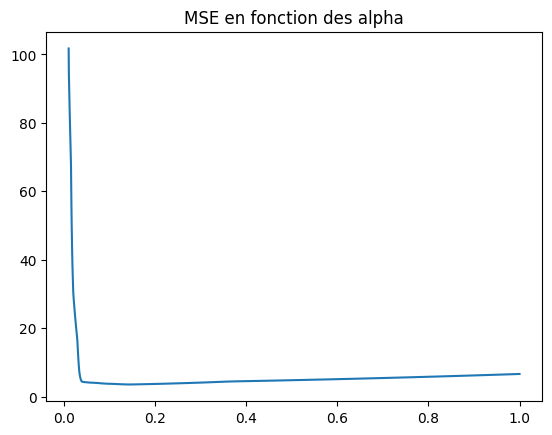

In [8]:
#2.4.2
from sklearn.preprocessing import StandardScaler

#centrer-réduire les variables
scaler = StandardScaler()
X_cr = scaler.fit_transform(X)

# fonction de calcul du s²
def s2(y_true, y_pred):
    n = len(y_true)
    SSE = np.sum((y_true - y_pred)**2)
    return SSE / (n-1)

# fonction de calcul de l'erreur/résidu
def calculate_err(X, y):
    X = np.array(X)
    y = np.array(y).flatten()
    
    # Gestion automatique des dimensions
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    
    n = len(y)
    residuals = np.zeros(n)
    
    for i in range(n):
        # Créer les données sans l'observation i
        X_train = np.vstack([X[:i], X[i+1:]]) 
        y_train = np.concatenate([y[:i], y[i+1:]])
        
        lr = LinearRegression().fit(X_train, y_train)
        residuals[i] = y[i] - lr.predict(X[i].reshape(1, -1))[0]
    
    return residuals


# détection et suppression des valeurs aberrantes
residuals=calculate_err(X_cr,Y)
num_D = residuals**2
D_cook = num_D/(2 * s2(Y, LinearRegression().fit(X_cr[:], Y).predict(X_cr[:]))**2 )
threshold = 1  
outlier_mask = D_cook > threshold
outlier_indices = np.where(outlier_mask)[0]

print(f"Outliers détectés (D_cook > {threshold}): {len(outlier_indices)}")
print(f"Indices des outliers: {outlier_indices}")

# Suppression des outliers
inlier_mask = ~outlier_mask
X_clean = X_cr[inlier_mask]
Y_clean = Y[inlier_mask]

print(f"Données originales: {X_cr.shape}")
print(f"Données nettoyées: {X_clean.shape}")

# Séparation des données entre celles de d'entraînement et celles de test
part_to_train = 0.3
index_to_train = int(len(X_clean)*part_to_train)
# X_train, X_test = X_clean[:index_to_train], X_clean[index_to_train:]
# y_train, y_test = Y_clean[:index_to_train], Y_clean[index_to_train:]
# print("to train :", len(X_train), " | to test :", len(X_test))

# Fonction de régression linéaire Lasso
def linear_regression2(X,y,n, alpha, title, plot=False):
    
    # séparation des X et y d'entraînement et de test selon le paramètre n de la fonction
    X_train = X[:n]
    y_train = y[:n]
    X_test = X[n:]
    y_test = y[n:]

    # création du modèle
    lasso = Lasso(alpha)
    lasso.fit(X_train, y_train)

    mse = mean_squared_error(y_test, lasso.predict(X_test))
    # print(title,f'\tmse={mse}')

    if (plot):
        # on fait la figure
        plt.figure()
        plt.plot(X_test, lasso.predict(X_test), 'b--')
        plt.plot(X_test, y_test, '.')
        mse = mean_squared_error(y_test, lasso.predict(X_test))
        plt.title(f'RegLin Eff/Conc {title}, mse={mse}')
    
    return mse, lasso.intercept_, lasso.coef_

# Calcul des variables par méthode Lasso, en testant différentes valeurs de alpha pour miniminer le mse.
alphas = np.logspace(-2,0,100)
mse_result = []
for alpha in alphas:
    mse_result.append(linear_regression2(X_clean,Y_clean,index_to_train, alpha, f'pour alpha = {alpha}')[0])
plt.figure()
plt.plot(alphas, mse_result)
plt.title('MSE en fonction des alpha')
# d'après ces résultats, on peut fixer alpha = 0.1 pour un mse proche du minimum

mse_final, intercept, coefs = linear_regression2(X_clean,Y_clean,index_to_train, 0.1, 'Régression linéaire finale')

print(f"Les coefficients finaux retenus sont :\nintercept :{intercept}\ncoefs : {coefs}")
non_nuls = abs(coefs) > 0
capteurs_gardes = np.arange(len(X_clean[:index_to_train]))[non_nuls]
print(f"Autrement dit, on garde les capteurs {capteurs_gardes+1}")
